In [1]:
!pip install openai python-dotenv

In [2]:
with open(".env", "w", encoding="utf-8") as f:
    f.write("OPENAI_API_KEY=sk-your-actual-key-here")

In [3]:
import os
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

print("API key loaded:", "Yes" if os.getenv("OPENAI_API_KEY") else "No")

API key loaded: Yes


In [4]:
from pathlib import Path

In [5]:
!pip install datasets
from datasets import load_dataset
import requests
from PIL import Image
import pandas as pd
 
# Load dataset from HuggingFace
print("Loading product dataset...")
try:
    # Try loading the dataset
    dataset = load_dataset("ashraq/fashion-product-images-small", split="train[:100]")  # First 100 samples
    print(f"✓ Loaded {len(dataset)} products")
    
    # Convert to pandas for easier manipulation
    products_df = pd.DataFrame(dataset)
    print(f"Dataset columns: {products_df.columns.tolist()}")
    
except Exception as e:
    print(f"⚠ Could not load HuggingFace dataset: {e}")
    print("Using local images instead...")
    
    # Alternative: Use local images
    # Create a products.json file with product information
    products_data = [
        {
            "id": 1,
            "name": "Wireless Headphones",
            "price": 79.99,
            "category": "Electronics",
            "image_path": "images/product1.jpg"
        },
        # Add more products...
    ]
    
    products_df = pd.DataFrame(products_data)
 
# Create images directory
images_dir = Path("product_images")
images_dir.mkdir(exist_ok=True)
 
print(f"\n✓ Dataset prepared!")
print(f"  Total products: {len(products_df)}")

c:\Users\eugnm\OneDrive\Desktop\ironhack\WEEK 1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading product dataset...


✓ Loaded 100 products
Dataset columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image']

✓ Dataset prepared!
  Total products: 100


In [6]:
for i, item in enumerate(dataset):
    image = item["image"]
    image.save(f"product_images/{i}.jpg")

print(f"Saved {len(dataset)} images to product_images/")

Saved 100 images to product_images/


In [7]:
from datasets import load_dataset

ds = load_dataset("ashraq/fashion-product-images-small")

In [8]:
import base64

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

# Test it with one of your product images
test_image = "product_images/0.jpg"  # adjust filename to match yours
encoded = encode_image(test_image)

# Checkpoint: verify it works
print(f"Image encoded successfully!")
print(f"First 50 characters: {encoded[:50]}...")
print(f"Encoded length: {len(encoded)} characters")

Image encoded successfully!
First 50 characters: /9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQ...
Encoded length: 2388 characters


In [9]:
import os
print(os.listdir("product_images"))

['0.jpg', '1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg', '16.jpg', '17.jpg', '18.jpg', '19.jpg', '2.jpg', '20.jpg', '21.jpg', '22.jpg', '23.jpg', '24.jpg', '25.jpg', '26.jpg', '27.jpg', '28.jpg', '29.jpg', '3.jpg', '30.jpg', '31.jpg', '32.jpg', '33.jpg', '34.jpg', '35.jpg', '36.jpg', '37.jpg', '38.jpg', '39.jpg', '4.jpg', '40.jpg', '41.jpg', '42.jpg', '43.jpg', '44.jpg', '45.jpg', '46.jpg', '47.jpg', '48.jpg', '49.jpg', '5.jpg', '50.jpg', '51.jpg', '52.jpg', '53.jpg', '54.jpg', '55.jpg', '56.jpg', '57.jpg', '58.jpg', '59.jpg', '6.jpg', '60.jpg', '61.jpg', '62.jpg', '63.jpg', '64.jpg', '65.jpg', '66.jpg', '67.jpg', '68.jpg', '69.jpg', '7.jpg', '70.jpg', '71.jpg', '72.jpg', '73.jpg', '74.jpg', '75.jpg', '76.jpg', '77.jpg', '78.jpg', '79.jpg', '8.jpg', '80.jpg', '81.jpg', '82.jpg', '83.jpg', '84.jpg', '85.jpg', '86.jpg', '87.jpg', '88.jpg', '89.jpg', '9.jpg', '90.jpg', '91.jpg', '92.jpg', '93.jpg', '94.jpg', '95.jpg', '96.jpg', '97.jpg', '98.jpg', '99.jpg']


In [ ]:
def create_product_listing_prompt(product_name, price, category, additional_info=None):
    prompt = f"""You are an expert e-commerce copywriter. Analyze the product image and create a compelling product listing.

Product Information:
- Name: {product_name}
- Price: ${price:.2f}
- Category: {category}
{f'- Additional Info: {additional_info}' if additional_info else ''}

Please create a professional product listing that includes:

1. **Product Title** (catchy, SEO-friendly, 60 characters max)
2. **Product Description** (detailed, 150-200 words)
3. **Key Features** (bullet points, 5-7 items)
4. **SEO Keywords** (comma-separated, 10-15 relevant keywords)

Format your response as JSON with the following structure:
{{
    "title": "Product title here",
    "description": "Full description here",
    "features": ["Feature 1", "Feature 2", ...],
    "keywords": "keyword1, keyword2, ..."
}}

Be specific about what you see in the image."""
    
    return prompt


In [11]:
#step 5


def generate_listing(image_path, product_name, price, category, additional_info=None):
    """Generate a product listing using GPT-4.1 vision."""
    
    base64_image = encode_image(image_path)
    prompt = create_product_listing_prompt(product_name, price, category, additional_info)

    response = client.chat.completions.create(
        model="gpt-4.1",
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": prompt
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{base64_image}"
                        }
                    }
                ]
            }
        ]
    )

    return response.choices[0].message.content


# --- Test with one product ---

result = generate_listing(
    image_path="product_images/0.jpg",
    product_name=products_df.iloc[0]["productDisplayName"],
    price=29.99,
    category=products_df.iloc[0]["masterCategory"]
)

# Display image + listing together
from IPython.display import display
from PIL import Image

display(Image.open("product_images/0.jpg"))
import json

parsed = json.loads(result.strip("```json").strip("```").strip())
print(json.dumps(parsed, indent=4))

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-your-****here. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

In [ ]:
#step 6

import json
import time

all_listings = []

# Process first 5 products (adjust range as needed)
for i in range(5):
    try:
        print(f"Processing product {i+1}/5...")
        
        result = generate_listing(
            image_path=f"product_images/{i}.jpg",
            product_name=products_df.iloc[i]["productDisplayName"],
            price=29.99,
            category=products_df.iloc[i]["masterCategory"]
        )
        
        # Parse JSON response
        cleaned = result.strip("```json").strip("```").strip()
        parsed = json.loads(cleaned)
        parsed["original_product"] = products_df.iloc[i]["productDisplayName"]
        all_listings.append(parsed)
        
        print(f"  ✓ {parsed['title']}")
        
        # Small delay to avoid rate limits
        time.sleep(2)
        
    except Exception as e:
        print(f"  ✗ Error on product {i}: {e}")
        continue

# Save results
with open("product_listings.json", "w") as f:
    json.dump(all_listings, f, indent=4)

print(f"\nDone! Generated {len(all_listings)} listings.")
print("Saved to product_listings.json")

Processing product 1/5...
  ✓ Classic Navy Blue Checkered Shirt for Men – Stylish & Comfortable
Processing product 2/5...
  ✓ Peter England Men's Stylish Blue Party Jeans – Slim Fit
Processing product 3/5...
  ✓ Elegant Titan Women’s Silver Watch – Minimalist Stainless Steel
Processing product 4/5...
  ✓ Manchester United Black Track Pants for Men – Athletic Comfort
Processing product 5/5...
  ✓ PUMA Men's Grey Polo T-Shirt – Classic Sporty Style

Done! Generated 5 listings.
Saved to product_listings.json


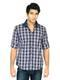


📌 Classic Navy Blue Checkered Shirt for Men – Stylish & Comfortable

Upgrade your wardrobe with the Turtle Check Men Navy Blue Shirt, crafted for the modern man who values both style and comfort. Featuring a timeless navy blue base with crisp white and soft blue checks, this shirt adds a touch of sophistication to any outfit. Made from premium, breathable cotton, it ensures all-day comfort whether you're at the office or out with friends. The shirt features a smart, semi-spread collar and full button-down front, making it versatile for both formal and casual occasions. Its tailored fit flatters your silhouette while allowing ease of movement, and the durable fabric ensures long-lasting wear. Pair this essential piece with jeans or chinos for an effortlessly dashing look.

Features:
  • Classic navy blue base with stylish check pattern
  • Breathable, soft cotton fabric for all-day comfort
  • Semi-spread collar adds a sharp, modern touch
  • Tailored fit for a flattering, contemporary

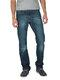


📌 Peter England Men's Stylish Blue Party Jeans – Slim Fit

Step out in confidence with Peter England Men Party Blue Jeans, designed for the modern man who loves to make an impression. These jeans feature a classic mid-blue wash with subtle fading and whiskering on the thighs for a contemporary, lived-in look that's perfect for parties and smart-casual occasions. Crafted from premium denim, they provide both comfort and durability for all-day wear. The flattering slim fit silhouette enhances your profile, while the five-pocket styling adds practicality and classic appeal. Team them with a crisp shirt for a party-ready statement or pair with a basic tee for effortless style. Elevate your wardrobe with this versatile addition, blending timeless design with on-trend detailing at an unbeatable price.

Features:
  • Rich mid-blue wash with subtle faded details
  • Slim fit for a modern, flattering silhouette
  • Durable, comfortable premium denim fabric
  • Classic five-pocket design for ve

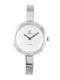


📌 Elegant Titan Women’s Silver Watch – Minimalist Stainless Steel

Refined elegance meets everyday functionality with the Titan Women Silver Watch. Featuring a sleek round dial in a luminous silver finish, this stunning timepiece is designed for the modern woman who values timeless style. The minimalist white face is accented by slim, contrasting hour and minute hands and classic Titan branding at the center. Its narrow stainless steel mesh strap offers both comfort and sophistication, making it perfect to wear from the office to an evening out. The secure clasp ensures a snug fit, while the scratch-resistant mineral glass protects the dial’s pristine finish. Add a touch of understated luxury to your accessory collection at an unbeatable price of $29.99. Whether gifting for a special occasion or treating yourself, this Titan watch is the ultimate statement of grace and quality.

Features:
  • Polished silver-tone stainless steel case and mesh band
  • Classic white round dial with min

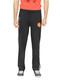


📌 Manchester United Black Track Pants for Men – Athletic Comfort

Show off your true colors with the Manchester United Men Solid Black Track Pants—designed for both die-hard supporters and stylish athletes. Featuring the iconic Manchester United club crest embroidered on the left thigh, these classic black track pants deliver a sleek and sporty look. The premium fabric ensures all-day comfort, whether you're at the gym, on a casual stroll, or watching the match from home. An elastic waistband provides a secure, customized fit, while the straight-leg cut offers freedom of movement. Convenient side pockets add functionality for carrying small essentials. Versatile and stylish, these track pants are a must-have addition to every Manchester United fan's wardrobe. Get yours today for just $29.99 and step up your game on and off the pitch!

Features:
  • Official Manchester United club crest on left thigh
  • Solid black color for versatile styling
  • Elasticated waistband with adjustable 

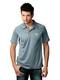


📌 PUMA Men's Grey Polo T-Shirt – Classic Sporty Style

Upgrade your wardrobe with the PUMA Men’s Grey Polo T-Shirt—a perfect blend of sporty flair and modern comfort. Featuring a sleek grey hue, this polo showcases the iconic PUMA logo on the left chest, making it a sophisticated yet casual pick for any occasion. The shirt is designed with a classic polo collar and button placket, offering a versatile look that pairs just as well with jeans as it does with athletic shorts. Crafted from soft, breathable fabric, it ensures all-day comfort and durability—ideal for both active and relaxed lifestyles. Whether you're hitting the gym, heading out for a weekend brunch, or just keeping it cool and casual, this PUMA polo is your go-to option. Make a statement with the subtle style and high-quality finish that only PUMA can deliver.

Features:
  • Iconic PUMA logo on chest for authentic sporty appeal
  • Stylish grey color pairs easily with any outfit
  • Classic polo collar with two-button plac

In [ ]:
from IPython.display import display
from PIL import Image

for i, listing in enumerate(all_listings):
    print("=" * 60)
    display(Image.open(f"product_images/{i}.jpg"))
    print(f"\n📌 {listing['title']}")
    print(f"\n{listing['description']}")
    print("\nFeatures:")
    for feature in listing['features']:
        print(f"  • {feature}")
    print(f"\nKeywords: {listing['keywords']}")
    print()

In [ ]:
def generate_listing_with_cost(image_path, product_name, price, category, additional_info=None):
    """Generate a product listing and track API costs."""
    
    base64_image = encode_image(image_path)
    prompt = create_product_listing_prompt(product_name, price, category, additional_info)

    response = client.chat.completions.create(
        model="gpt-4.1",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{base64_image}"
                        }
                    }
                ]
            }
        ]
    )

    # Extract token usage
    usage = response.usage
    cost = {
        "input_tokens": usage.prompt_tokens,
        "output_tokens": usage.completion_tokens,
        "total_tokens": usage.total_tokens,
        "input_cost": usage.prompt_tokens * (2.00 / 1_000_000),   # gpt-4.1 input price
        "output_cost": usage.completion_tokens * (8.00 / 1_000_000),  # gpt-4.1 output price
    }
    cost["total_cost"] = cost["input_cost"] + cost["output_cost"]

    return response.choices[0].message.content, cost


# Run batch with cost tracking
import time

all_listings = []
all_costs = []

for i in range(5):
    try:
        print(f"Processing product {i+1}/5...")
        
        result, cost = generate_listing_with_cost(
            image_path=f"product_images/{i}.jpg",
            product_name=products_df.iloc[i]["productDisplayName"],
            price=29.99,
            category=products_df.iloc[i]["masterCategory"]
        )
        
        cleaned = result.strip("```json").strip("```").strip()
        parsed = json.loads(cleaned)
        all_listings.append(parsed)
        all_costs.append(cost)
        
        print(f"  ✓ {parsed['title']}")
        print(f"    Tokens: {cost['total_tokens']} | Cost: ${cost['total_cost']:.4f}")
        
        time.sleep(2)
        
    except Exception as e:
        print(f"  ✗ Error on product {i}: {e}")
        continue

# Summary
total_tokens = sum(c["total_tokens"] for c in all_costs)
total_cost = sum(c["total_cost"] for c in all_costs)

print(f"\n{'=' * 50}")
print(f"COST SUMMARY")
print(f"{'=' * 50}")
print(f"Products processed: {len(all_costs)}")
print(f"Total tokens used:  {total_tokens:,}")
print(f"Total cost:         ${total_cost:.4f}")
print(f"Avg cost per item:  ${total_cost / len(all_costs):.4f}")
print(f"\nEstimated cost for 100 products: ${(total_cost / len(all_costs)) * 100:.2f}")
print(f"Estimated cost for 1000 products: ${(total_cost / len(all_costs)) * 1000:.2f}")

Processing product 1/5...
  ✓ Turtle Check Navy Blue Casual Shirt for Men – Stylish Comfort
    Tokens: 792 | Cost: $0.0036
Processing product 2/5...
  ✓ Peter England Men's Blue Party Jeans – Stylish Slim Fit Denim
    Tokens: 772 | Cost: $0.0035
Processing product 3/5...
  ✓ Elegant Titan Women’s Silver Watch – Minimalist Classic Style
    Tokens: 763 | Cost: $0.0034
Processing product 4/5...
  ✓ Manchester United Men's Black Track Pants – Official Fanwear
    Tokens: 782 | Cost: $0.0035
Processing product 5/5...
  ✓ Puma Men's Grey Polo T-Shirt – Classic Comfort and Style
    Tokens: 771 | Cost: $0.0035

COST SUMMARY
Products processed: 5
Total tokens used:  3,880
Total cost:         $0.0175
Avg cost per item:  $0.0035

Estimated cost for 100 products: $0.35
Estimated cost for 1000 products: $3.50
